# Dependence & causality toolkit, horizon requirements, and sensor placement

Three questions, in the order you need them answered:

1. **What is the toolkit, and does it measure what it claims to?** (Part 1)
2. **How much data does it need before it's useful?** (Part 2)
3. **Given that, does placement change what it detects?** (Part 3, carried
   over from the placement-only notebook, now read in light of Parts 1–2.)

**What every AUROC in this notebook classifies.** For a district pair, does
`|statistic|` rank pairs that **share an open boundary pipe** (label = 1)
above pairs that **don't** (label = 0)? It is not classifying time points —
one number per pair, and AUROC is the Mann–Whitney concordance
P(stat on a random adjacent pair > stat on a random non-adjacent pair).
0.5 = chance, 1.0 = every adjacent pair outranks every non-adjacent one.

Run on `coupling.variant: baseline` throughout: under `partial`, a closed
boundary pipe is both a topological input a strategy can see and the label,
so a topology-driven placement would leak.

In [22]:
import sys, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd().resolve()
PROJ = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)
for p in (PROJ / "src", PROJ / "notebooks", PROJ, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
import fedwater
import placement_poc as P

SEED = 0
pd.set_option("display.width", 160)

index = P.discover_worlds(PROJ)
usable = index[index.usable & (index.variant == "baseline")]
print(f"{len(index)} cached worlds | usable baseline: {len(usable)}")
if not len(usable):
    raise SystemExit("No usable baseline worlds -- build some first.")

art0 = P.load_world(usable.iloc[0]["dir"])
T = len(art0["pressures"])
print(f"typical horizon T = {T} steps")

43 cached worlds | usable baseline: 43
typical horizon T = 21600 steps


In [25]:
tgt_test = ['4926bde37a8a', '987ddeef40de', '5f1bf78de226']
usable = usable[usable['sim_hash'].isin(tgt_test)]

---
# Part 1 — the dependence/causality toolkit

## 1.1 Method catalog

Six statistics, two axes: **scope** (does it reduce a district to its mean
signal, or use the full sensor matrix?) and **directional** (symmetric
association, or does it distinguish a→b from b→a?).

In [2]:
display(P.METHOD_CATALOG)

,method,scope,directional,null,measures
0,pearson,signal (district mean),False,circular time-shift surrogate,raw co-movement of the two district MEANS
1,partial_corr,"signal, other districts partialled out",False,none (point estimate),pearson with every OTHER district's mean regre...
2,rv,matrix (all of a district's sensors),False,circular time-shift surrogate (block roll),pearson generalized to two SENSOR MATRICES; do...
3,partial_rv,"matrix, other districts partialled out",False,circular time-shift surrogate (block roll),rv with the other districts' matrices projecte...
4,granger_max,"signal, directional",True,none here (F-statistic only),"max(F(a->b), F(b->a)) -- does one district's p..."
5,lead_lag_h,"signal, directional",True,none (descriptive),lag (steps) where cross-correlation peaks -- w...


## 1.2 Worked example — one real pair, every method

Same computation `pair_scores` runs for every one of the C(5,2)=10 pairs at
once, unrolled here for one pair so the mechanics are legible. `partial_corr`
/ `partial_rv` additionally regress out every OTHER district before comparing
the two in question — the shared-driver check.

In [ ]:
w0 = usable.iloc[0]
cands0 = P.candidate_table(art0["wn"], art0["districts"])
feats0, dist0 = P.topology_features(art0["wn"], art0["districts"], cands0)
stats0 = P.residual_stats(art0["pressures"], art0["flows"], cands0, art0["steps_day"])
pls0 = P.strategies(cands0, feats0, stats0, dist0, art0["params"], seed=SEED)

ss0 = P.build_series(art0["pressures"], art0["flows"], pls0["variance"])
ss0 = ss0[ss0["kind"] == "flow"]
mats0, sigs0 = P.district_data(ss0, art0["steps_day"])
ds0 = sorted(art0["districts"]["districts"])
print(w0["tag"], "| districts:", ds0)

display(P.explain_pair(mats0, sigs0, ds0[0], ds0[1], "flow", n_sur=99, seed=SEED))

Elr__LI_LC_LR_LI_LC__baseline | districts: ['District_A', 'District_B', 'District_C', 'District_D', 'District_E']


,method,statistic,p_value,measures
0,pearson,0.828931,0.01,raw co-movement of district MEANS
1,partial_corr,0.245589,NaN,pearson with other districts regressed out
2,rv,0.650394,0.01,pearson generalized to the full sensor MATRIX
3,partial_rv,0.061121,0.01,rv with other districts' matrices projected out
4,granger_District_A->District_B,13.858394,NaN,does District_A's past predict District_B's fu...
5,granger_District_B->District_A,30.041791,NaN,does District_B's past predict District_A's fu...
6,lead_lag_h,0.000000,NaN,lag (steps) where cross-corr peaks; sign = who...


## 1.3 Known-truth validation

A synthetic system with a KNOWN answer: `a -> b` at lag 1 (coupled), `c`
independent of `a`, and a mediated chain `a -> mid -> far` (correlated with
`a` through `mid`, with no direct edge). Run at this study's own horizon `T`
— the verdict is about this design, not about some textbook `n`.

In [4]:
sc_truth = P.sc_estimators_known_truth(T, seed=SEED)
display(sc_truth)
if not sc_truth["passed"].all():
    print("FAILED:", list(sc_truth.loc[~sc_truth.passed, "check"]),
          "-- stop here, the toolkit disagrees with a known answer.")

,check,value,passed
0,coupled_detected,0.010000,True
1,independent_not_detected,0.320000,True
2,granger_direction,1591.499711,True
3,lead_lag_is_1,1.000000,True
4,mediated_path_suppressed,0.008221,True
5,rv_separates,0.999771,True


---
# Part 2 — horizon sensitivity: how much data does this need?

Three complementary views: (a) synthetic power curves — detection rate on a
KNOWN system as a function of `n`; (b) split-half stability on real
residuals; (c) does the placement AUROC itself only emerge past some `n`?

## 2.1 Synthetic power curves

`n_rep` independent draws per horizon; the rate over reps is a Monte-Carlo
power estimate, not one lucky seed. Six rows: detection power (coupled),
false-positive rate (independent — should stay low), direction recovery,
lag recovery, mediation suppression, and RV separation.

In [ ]:
NS_SYNTH = (84, 336, 1008, 2016, 4320, 8640, 21600)
power = P.known_truth_power(ns=NS_SYNTH, n_rep=30, n_sur=49, seed=SEED)
display(power.round(3))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for col in ["power_coupled", "fpr_independent", "direction_correct",
           "lag_correct", "mediation_suppressed", "rv_separates"]:
    ax.plot(power["n"], power[col], marker="o", ms=3, label=col)
ax.set_xscale("log"); ax.axhline(0.05, ls=":", c="grey", lw=.8)
ax.axhline(0.8, ls="--", c="grey", lw=.8)
ax.set_xlabel("horizon n (steps)"); ax.set_ylabel("rate over reps")
ax.legend(fontsize=7, ncol=2); fig.tight_layout(); plt.show()

## 2.2 Real-data split-half stability

Same statistic computed on the first vs last `n` steps of a real placement's
residuals. The spread between the two columns at a given `n` is the honest
error bar on that statistic — not a p-value, a direct look at estimator
variance on this network's actual data.

In [ ]:
tags = usable["tag"].tolist()[:3]
for _, w in usable[usable.tag.isin(tags)].iterrows():
    art = P.load_world(w["dir"])
    cands = P.candidate_table(art["wn"], art["districts"])
    feats, dist = P.topology_features(art["wn"], art["districts"], cands)
    stats = P.residual_stats(art["pressures"], art["flows"], cands, art["steps_day"])
    pls = P.strategies(cands, feats, stats, dist, art["params"], seed=SEED)

    ss = P.build_series(art["pressures"], art["flows"], pls["variance"])
    ss = ss[ss["kind"] == "flow"]
    mats, sigs = P.district_data(ss, art["steps_day"])
    ds = sorted(art["districts"]["districts"])
    print(w["tag"])
    display(P.sc_sample_size(mats, sigs, [84, 336, 2016, 8640, len(art["pressures"])],
                             (ds[0], ds[1]), "flow", n_sur=49, seed=SEED))

## 2.3 Does the placement AUROC itself need a minimum horizon?

Fix ONE placement (`variance` — the non-circular strategy from Part 3) and
truncate real residuals to the first `n` steps, exactly as if that's all the
data available so far. `pooled_auroc` rank-normalizes within each world
before pooling, so this is comparable across the world subset below.

A handful of worlds, to bound runtime — widen `WORLDS_SUBSET` for a fuller
answer once the shape of the curve is clear.

In [ ]:
WORLDS_SUBSET = usable.iloc[:8]
NS_REAL = (84, 336, 1008, 2016, 4320, 8640, T)

prepared = {}
for _, w in WORLDS_SUBSET.iterrows():
    art = P.load_world(w["dir"])
    cands = P.candidate_table(art["wn"], art["districts"])
    feats, dist = P.topology_features(art["wn"], art["districts"], cands)
    stats = P.residual_stats(art["pressures"], art["flows"], cands, art["steps_day"])
    pls = P.strategies(cands, feats, stats, dist, art["params"], seed=SEED)
    prepared[w["tag"]] = P.prepare_world_for_horizon(art, pls["variance"], "flow")

hs = P.horizon_scores(prepared, NS_REAL,
                      methods=("pearson", "rv", "partial_rv", "partial_corr"),
                      n_sur=49, seed=SEED)
avh = P.auroc_vs_horizon(hs)
display(avh.pivot(index="n", columns="method", values="pooled_auroc").round(3))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for m, g in avh.groupby("method"):
    ax.plot(g["n"], g["pooled_auroc"], marker="o", ms=3, label=m)
ax.set_xscale("log"); ax.axhline(0.5, ls="--", c="grey", lw=.8)
ax.set_xlabel("horizon n (steps)"); ax.set_ylabel("pooled AUROC")
ax.set_title(f"placement fixed at `variance` -- {len(prepared)} worlds")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

---
# Part 3 — placement, evaluated across worlds

Carried over from the placement-only notebook. Five strategies through one
greedy: `manual` / `random` / `variance` (client-local, no topology) /
`spread` (max graph separation, no gain term) / `boundary` (proximity to
boundary pipes + carry). `boundary` is partly circular against this AUROC
label — `variance` is the strategy to trust when both clear the bar.

In [ ]:
KINDS   = ("flow",)
METHODS = ("partial_corr", "partial_rv", "pearson", "rv")
N_SUR   = 49

display(usable.groupby(usable["tag"].str.split("__").str[1]).size()
        .rename("n_worlds").to_frame().T)

In [ ]:
scores, diags, notes = P.sweep_worlds(
    usable, kinds=KINDS, methods=METHODS, n_sur=N_SUR, seed=SEED, noise=False)
print(f"scored {scores['sim_hash'].nunique()} worlds, {len(scores)} pair-statistics")
if len(notes):
    display(notes)

## 3.1 Pressure vs flow, and topology vs physics — replicated diagnostics

In [ ]:
pvf = diags[diags.check == "pressure_vs_flow"]
display(pvf.groupby("kind")[["within_abs_corr", "across_abs_corr",
                             "discriminative_gap"]].agg(["mean", "min", "max"]).round(4))

## 3.2 Per-world recovery, pooled AUROC, and paired comparison vs `manual`

Paired per world is the right unit for the comparison: world-to-world
variation is shared across strategies within a world, so the delta has far
less variance than either AUROC alone.

In [ ]:
rec = P.recovery_by_world(scores)
display(rec.pivot_table(index=["kind", "method"], columns="strategy",
                        values="auroc", aggfunc=["mean", "std"]).round(3))

In [ ]:
pool = P.pooled_auroc(scores)
display(pool.round(3))

In [ ]:
paired = P.paired_vs_reference(rec, ref="manual", n_boot=2000, seed=SEED)
display(paired[paired.ci_lo > 0].round(3))

## 3.3 Is the effect bigger than world-to-world noise?

In [ ]:
for m in ("partial_rv", "partial_corr"):
    print(f"-- {m} / flow")
    display(P.variance_share(rec, method=m, kind="flow").round(3))

In [ ]:
METHOD = "partial_rv"
g = rec[(rec.method == METHOD) & (rec.kind == "flow")]
order = g.groupby("strategy")["auroc"].mean().sort_values().index.tolist()
rng = np.random.default_rng(SEED)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for i, s in enumerate(order):
    v = g.loc[g.strategy == s, "auroc"].to_numpy()
    ax[0].scatter(np.full(len(v), i) + rng.normal(0, .06, len(v)), v, alpha=.7, s=26)
    ax[0].plot([i - .25, i + .25], [v.mean()] * 2, c="k", lw=2)
ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(order, rotation=30)
ax[0].axhline(0.5, ls="--", c="grey", lw=.8); ax[0].set_ylim(0, 1.05)
ax[0].set_title(f"{METHOD} / flow -- per-world AUROC")

pv = paired[(paired.method == METHOD) & (paired.kind == "flow")] \
    .set_index("strategy").reindex([o for o in order if o != "manual"])
ax[1].barh(pv.index, pv["mean_delta"],
          xerr=[pv["mean_delta"] - pv["ci_lo"], pv["ci_hi"] - pv["mean_delta"]],
          capsize=3, color="tab:orange")
ax[1].axvline(0, c="k", lw=.8)
ax[1].set_xlabel("mean AUROC delta vs manual (95% CI over worlds)")
fig.tight_layout(); plt.show()

---
# Part 4 — direction: is the dependence causal, and is it physical?

Parts 1–3 use symmetric statistics against a symmetric label (pair shares an
open boundary pipe), so they validate *magnitude* only. Nothing so far says
anything about `B -> C`.

This part adds direction, and — more importantly — tests whether the
directional claim is trustworthy at all. Order matters: 4.1 asks whether the
coupling has *any* temporal structure to infer direction from. If it doesn't,
everything downstream of it is decoration.

## 4.1 Does the coupling have temporal structure? (run this first)

Cross-correlation at every lag. Granger causality infers direction from
**temporal precedence** — if the profile peaks sharply at lag 0, hydraulic
redistribution is effectively instantaneous at this resolution, there is no
precedence to exploit, and any Granger asymmetry is measuring something else.

Dlc__LR_LC_LC_LI_LR__baseline | placement=variance


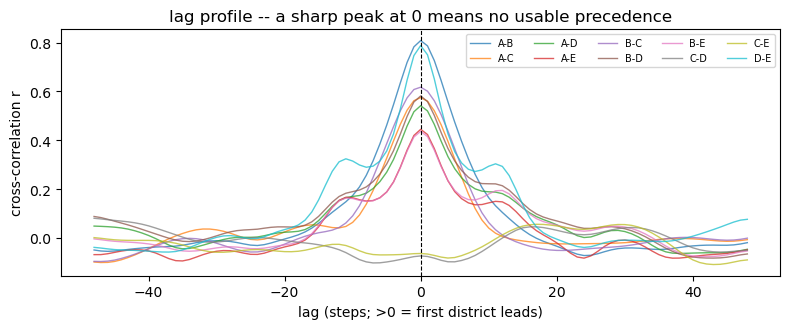

,pair,peak_lag,peak_r,r_at_lag0
0,District_A-District_B,0,0.808,0.808
1,District_A-District_C,0,0.575,0.575
2,District_A-District_D,0,0.542,0.542
3,District_A-District_E,0,0.445,0.445
4,District_B-District_C,0,0.617,0.617
5,District_B-District_D,0,0.581,0.581
6,District_B-District_E,0,0.436,0.436
7,District_C-District_D,-7,-0.103,-0.074
8,District_C-District_E,43,-0.109,-0.064
9,District_D-District_E,0,0.788,0.788


peak-lag == 0 for all pairs: False


In [26]:
art0 = P.load_world(usable.iloc[0]["dir"])
cands0 = P.candidate_table(art0["wn"], art0["districts"])
feats0, dist0 = P.topology_features(art0["wn"], art0["districts"], cands0)
stats0 = P.residual_stats(art0["pressures"], art0["flows"], cands0, art0["steps_day"])
PLACEMENT = "variance"          # explicit -- direction results depend on it
pls0 = P.strategies(cands0, feats0, stats0, dist0, art0["params"], seed=SEED)

ss0 = P.build_series(art0["pressures"], art0["flows"], pls0[PLACEMENT])
ss0 = ss0[ss0["kind"] == "flow"]
mats0, sigs0 = P.district_data(ss0, art0["steps_day"])
ds0 = sorted(art0["districts"]["districts"])
print(f"{usable.iloc[0]['tag']} | placement={PLACEMENT}")

fig, ax = plt.subplots(figsize=(8, 3.4))
for i, a in enumerate(ds0):
    for b in ds0[i + 1:]:
        lp = P.lag_profile(sigs0, a, b, "flow", max_lag=48)
        ax.plot(lp["lag"], lp["r"], lw=1, alpha=.75,
                label=f"{a[-1]}-{b[-1]}")
ax.axvline(0, c="k", lw=.8, ls="--")
ax.set_xlabel("lag (steps; >0 = first district leads)")
ax.set_ylabel("cross-correlation r")
ax.set_title("lag profile -- a sharp peak at 0 means no usable precedence")
ax.legend(fontsize=7, ncol=5); fig.tight_layout(); plt.show()

rows = []
for i, a in enumerate(ds0):
    for b in ds0[i + 1:]:
        lp = P.lag_profile(sigs0, a, b, "flow", max_lag=48)
        top = lp.loc[lp["r"].abs().idxmax()]
        rows.append({"pair": f"{a}-{b}", "peak_lag": int(top["lag"]),
                     "peak_r": round(float(top["r"]), 3),
                     "r_at_lag0": round(float(lp.loc[lp.lag == 0, "r"].iloc[0]), 3)})
peaks = pd.DataFrame(rows)
display(peaks)
print("peak-lag == 0 for all pairs:", bool((peaks["peak_lag"] == 0).all()))

## 4.2 The directed measures

`directed_scores` keeps both Granger directions side by side instead of
collapsing them to `max(...)`. `granger_with_null` adds a circular-shift
surrogate p-value to each direction — the shift destroys cross-dependence
while preserving each series' own autocorrelation, so an F that survives is
genuine cross-prediction rather than one district simply being more
self-predictable. Raw F values are not comparable across pairs without it.

In [27]:
LAGS = 24
directed = P.directed_scores(mats0, sigs0, "flow", lags=LAGS, max_lag=48)
gnull    = P.granger_with_null(sigs0, "flow", lags=LAGS, n_sur=99, seed=SEED)
display(directed.merge(gnull, on=["district_a", "district_b"])
        [["district_a", "district_b", "granger_a_to_b", "granger_b_to_a",
          "direction_ratio", "p_a_to_b", "p_b_to_a", "verdict_at_05",
          "lead_lag_steps", "lead_lag_leader"]].round(4))

,district_a,district_b,granger_a_to_b,granger_b_to_a,direction_ratio,p_a_to_b,p_b_to_a,verdict_at_05,lead_lag_steps,lead_lag_leader
0,District_A,District_B,3.8649,84.7107,0.0456,0.01,0.01,bidirectional,0,simultaneous
1,District_A,District_C,40.4418,72.1625,0.5604,0.01,0.01,bidirectional,0,simultaneous
2,District_A,District_D,7.8622,158.6553,0.0496,0.01,0.01,bidirectional,0,simultaneous
3,District_A,District_E,8.5525,16.7718,0.5099,0.01,0.01,bidirectional,0,simultaneous
4,District_B,District_C,44.8906,57.1964,0.7849,0.01,0.01,bidirectional,0,simultaneous
5,District_B,District_D,5.9626,127.9117,0.0466,0.01,0.01,bidirectional,0,simultaneous
6,District_B,District_E,5.6478,100.5159,0.0562,0.01,0.01,bidirectional,0,simultaneous
7,District_C,District_D,41.6802,25.5269,1.6328,0.01,0.01,bidirectional,7,District_D
8,District_C,District_E,32.4353,14.8225,2.1883,0.01,0.01,bidirectional,43,District_C
9,District_D,District_E,7.9061,186.0670,0.0425,0.01,0.01,bidirectional,0,simultaneous


## 4.3 Sanity checks on the directional claim

Two unforgiving diagnostics:

- **Time reversal.** Genuine temporal causation should weaken or flip when
  the series are reversed. `survives_reversal=True` means the asymmetry comes
  from static properties of the series, not direction of influence.
- **Self-predictability confound.** If `direction_ratio` tracks the difference
  in each district's own AR R², the "causality" is that confound.

In [28]:
rev = P.reverse_time_control(sigs0, "flow", lags=LAGS)
display(rev.round(3))
print(f"survives reversal (=> artifact): {int(rev.survives_reversal.sum())}"
      f"/{len(rev)} pairs")

ac = P.autocorr_confound(sigs0, "flow", lags=LAGS)
display(ac.round(4))

chk = directed.merge(ac.rename(columns={"district": "district_a",
                                        "ar_r2": "ar_r2_a"}), on="district_a") \
             .merge(ac.rename(columns={"district": "district_b",
                                       "ar_r2": "ar_r2_b"}), on="district_b")
chk["ar_r2_diff"] = chk["ar_r2_a"] - chk["ar_r2_b"]
rho = chk[["ar_r2_diff"]].assign(lr=np.log(chk["direction_ratio"].clip(1e-9))) \
                         .corr(method="spearman").iloc[0, 1]
print(f"Spearman(log direction_ratio, AR-R2 difference) = {rho:.3f}"
      "   <- near +/-1 means the direction IS the confound")

,district_a,district_b,ratio_forward,ratio_reversed,survives_reversal
0,District_A,District_B,0.046,0.066,True
1,District_A,District_C,0.560,1.682,False
2,District_A,District_D,0.050,0.039,True
3,District_A,District_E,0.510,0.280,True
4,District_B,District_C,0.785,2.927,False
5,District_B,District_D,0.047,0.041,True
6,District_B,District_E,0.056,0.053,True
7,District_C,District_D,1.633,0.293,False
8,District_C,District_E,2.188,0.249,False
9,District_D,District_E,0.042,0.047,True


survives reversal (=> artifact): 6/10 pairs


,district,ar_r2
0,District_A,0.9860
1,District_B,0.9873
2,District_C,0.9815
3,District_D,0.9701
4,District_E,0.9845


Spearman(log direction_ratio, AR-R2 difference) = 0.115   <- near +/-1 means the direction IS the confound


## 4.4 Physical directional ground truth

The one directional label the simulation genuinely provides: **the sign of
flow through the boundary pipes**. wntr flowrate is signed start→end, so the
mean tells you which district supplies which.

`reversal_frac` / `stable_direction` is the necessary caveat — a pair whose
interconnection reverses sign over the day (tank filling/draining) has no
stable physical direction, and no method can or should recover one.

In [29]:
phys = P.boundary_flow_direction(art0)
display(phys.round(4))
print(f"pairs with a STABLE physical direction: "
      f"{int(phys.stable_direction.sum())}/{len(phys)}")

cmp = directed.merge(phys, on=["district_a", "district_b"], how="inner")
cmp["granger_matches"] = cmp["dominant_direction"] == cmp["physical_direction"]
display(cmp[["district_a", "district_b", "dominant_direction",
             "physical_direction", "granger_matches", "direction_ratio",
             "transfer_strength", "stable_direction"]])
stable = cmp[cmp.stable_direction]
if len(stable):
    print(f"Granger direction matches physics on stable pairs: "
          f"{stable.granger_matches.mean():.2f} "
          f"({int(stable.granger_matches.sum())}/{len(stable)}); "
          "0.5 = chance")

,district_a,district_b,n_boundary_pipes,net_q_a_to_b,physical_direction,transfer_strength,reversal_frac,stable_direction
0,District_A,District_B,1,37.7662,District_A->District_B,37.7662,0.3501,False
1,District_A,District_C,1,29.3814,District_A->District_C,29.3814,0.3178,False
2,District_B,District_C,1,13.2647,District_B->District_C,13.2647,0.3321,False
3,District_C,District_D,2,34.3649,District_C->District_D,34.3649,0.3138,False
4,District_D,District_E,4,12.5644,District_D->District_E,15.3683,0.4039,False


pairs with a STABLE physical direction: 0/5


,district_a,district_b,dominant_direction,physical_direction,granger_matches,direction_ratio,transfer_strength,stable_direction
0,District_A,District_B,District_B->District_A,District_A->District_B,False,0.045625,37.766198,False
1,District_A,District_C,District_C->District_A,District_A->District_C,False,0.560426,29.381359,False
2,District_B,District_C,District_C->District_B,District_B->District_C,False,0.784850,13.264657,False
3,District_C,District_D,District_C->District_D,District_C->District_D,True,1.632794,34.364922,False
4,District_D,District_E,District_E->District_D,District_D->District_E,False,0.042490,15.368330,False


## 4.5 Across worlds — is the direction invariant to consumption regime?

The actual test of physicality. A hydraulic coupling must give the same
direction whatever the consumption regime; if the answer moves with the
regime, the measure is tracking demand structure, not water transfer.

`regime_invariance` separates the two failure modes: `min_within_regime_agreement`
high but `n_regimes_agreeing < n_regimes` means each regime is internally
consistent yet they disagree with each other — regime-driven, not physical.

Subsampled and capped to keep runtime sane; widen once the pattern is clear.

In [30]:
N_WORLDS_DIR = 12
SUBSAMPLE    = 4320          # contiguous chunk for lag-structure methods
per = max(1, N_WORLDS_DIR // usable["consumption_map"].nunique())
sub = pd.concat([g.head(per) for _, g in usable.groupby("consumption_map")])
print(f"{len(sub)} worlds across {sub.consumption_map.nunique()} regimes")

alld, dnotes = P.sweep_directed(sub, placement=PLACEMENT, kind="flow",
                                lags=LAGS, n_sur=49, seed=SEED,
                                subsample=SUBSAMPLE)
if len(dnotes):
    display(dnotes)
print("rows:", len(alld))

3 worlds across 1 regimes
[1/3] Dlc__LR_LC_LC_LI_LR__baseline 39s
[2/3] Dlc__LR_LC_LC_LI_LR__baseline 23s
[3/3] Dlc__LR_LC_LC_LI_LR__baseline 22s
rows: 30


In [31]:
display(P.directed_consistency(alld, group="consumption_map").round(3))

,district_a,district_b,consumption_map,n_worlds,modal_direction,modal_agreement,median_ratio,match_physical_rate,survives_reversal_rate,physical_direction,physical_stable_rate
0,District_A,District_B,LR_LC_LC_LI_LR,3,District_B->District_A,1.000,0.093,0.000,1.000,District_A->District_B,0.0
1,District_A,District_C,LR_LC_LC_LI_LR,3,District_A->District_C,1.000,2.077,1.000,0.000,District_A->District_C,0.0
2,District_A,District_D,LR_LC_LC_LI_LR,3,District_D->District_A,1.000,0.070,0.000,1.000,None,NaN
3,District_A,District_E,LR_LC_LC_LI_LR,3,District_A->District_E,1.000,1.257,0.000,0.667,None,NaN
4,District_B,District_C,LR_LC_LC_LI_LR,3,District_B->District_C,0.667,1.774,0.667,0.667,District_B->District_C,0.0
5,District_B,District_D,LR_LC_LC_LI_LR,3,District_D->District_B,1.000,0.141,0.000,1.000,None,NaN
6,District_B,District_E,LR_LC_LC_LI_LR,3,District_E->District_B,0.667,0.286,0.000,1.000,None,NaN
7,District_C,District_D,LR_LC_LC_LI_LR,3,District_D->District_C,0.667,0.857,0.333,0.000,District_C->District_D,0.0
8,District_C,District_E,LR_LC_LC_LI_LR,3,District_E->District_C,0.667,0.753,0.000,0.333,None,NaN
9,District_D,District_E,LR_LC_LC_LI_LR,3,District_E->District_D,0.667,0.215,0.333,0.667,District_D->District_E,0.0


In [32]:
inv = P.regime_invariance(alld, by="consumption_map")
display(inv)
print(f"\ninvariant pairs: {int(inv.invariant.sum())}/{len(inv)}")
if "matches_physical" in inv:
    print(f"overall direction matches physics: "
          f"{int(inv.matches_physical.sum())}/{len(inv)} (0.5 = chance)")
print(f"asymmetry survives time reversal (artifact) on average: "
      f"{alld.survives_reversal.mean():.2f}")

,district_a,district_b,n_regimes,overall_direction,n_regimes_agreeing,invariant,min_within_regime_agreement,physical_direction,matches_physical
0,District_A,District_B,1,District_B->District_A,1,True,1.000000,District_A->District_B,False
1,District_A,District_C,1,District_A->District_C,1,True,1.000000,District_A->District_C,True
2,District_A,District_D,1,District_D->District_A,1,True,1.000000,None,False
3,District_A,District_E,1,District_A->District_E,1,True,1.000000,None,False
4,District_B,District_C,1,District_B->District_C,1,True,0.666667,District_B->District_C,True
5,District_B,District_D,1,District_D->District_B,1,True,1.000000,None,False
6,District_B,District_E,1,District_E->District_B,1,True,0.666667,None,False
7,District_C,District_D,1,District_D->District_C,1,True,0.666667,District_C->District_D,False
8,District_C,District_E,1,District_E->District_C,1,True,0.666667,None,False
9,District_D,District_E,1,District_E->District_D,1,True,0.666667,District_D->District_E,False



invariant pairs: 10/10
overall direction matches physics: 2/10 (0.5 = chance)
asymmetry survives time reversal (artifact) on average: 0.63


In [33]:
piv = (alld.assign(sig=lambda d: (d.p_a_to_b < 0.05) | (d.p_b_to_a < 0.05))
       .groupby(["district_a", "district_b"])
       .agg(sig_rate=("sig", "mean"),
            match_phys=("granger_matches_physical", "mean"),
            artifact_rate=("survives_reversal", "mean"),
            median_ratio=("direction_ratio", "median")).round(3))
display(piv)

sig_rate  match_phys  artifact_rate  median_ratio
district_a district_b                                                   
District_A District_B     1.000       0.000          1.000         0.093
           District_C     0.333       1.000          0.000         2.077
           District_D     1.000       0.000          1.000         0.070
           District_E     0.667       0.000          0.667         1.257
District_B District_C     0.333       0.667          0.667         1.774
           District_D     1.000       0.000          1.000         0.141
           District_E     1.000       0.000          1.000         0.286
District_C District_D     0.333       0.333          0.000         0.857
           District_E     0.333       0.000          0.333         0.753
District_D District_E     1.000       0.333          0.667         0.215

## 4.6 Verdict template

Fill from the cells above — the conclusion follows mechanically:

| observation | conclusion |
|---|---|
| peak lag = 0 for all pairs (4.1) | no temporal precedence; Granger direction is not identifiable at this resolution |
| `verdict_at_05` mostly `"none"` (4.2) | raw F asymmetries were uncalibrated; little survives a proper null |
| `survives_reversal` mostly True (4.3) | asymmetry is a static-property artifact |
| Spearman(ratio, AR-R2 diff) near ±1 (4.3) | the "direction" is the self-predictability confound |
| `match_phys` ≈ 0.5 (4.4/4.5) | Granger direction is no better than chance against real flow direction |
| `invariant` False for most pairs (4.5) | measured direction tracks the consumption regime, not hydraulics |

If that is the pattern, the defensible claim is: **hydraulic coupling on this
network is contemporaneous at hourly resolution, so directionality is not
recoverable from lag-based causality** — while `boundary_flow_direction` still
provides a genuine directed dependence measure from the physics, and the
symmetric statistics of Parts 1–3 remain valid for *strength*.

Routes to data-driven direction, if it's needed: sub-hourly resolution so
transport lag becomes resolvable, or an instantaneous causal-discovery method
(e.g. LiNGAM-family) rather than a lag-based one.

---
# Part 5 — is the drift/regime mixture the problem?

Hypothesis: over 30 months the consumption regime changes (one district
drifts), so the series are non-stationary and the diagnostics are measuring a
mixture rather than one regime. Restricting to the first 2–3 months gives a
single, stationary, guaranteed pre-drift regime (`fl.reference_months` is the
simulator's drift warm-up).

Two things to hold in mind, because they cut against the hypothesis:

- **Month-aware deseasonalization already removes per-month profile**, so the
  drift may have been subtracted out all along. `month_aware=False` is
  therefore tested alongside — on a short single-regime window, per-month
  profiles are fitted from ~30 days each and start absorbing the signal.
- **A short window costs sample size**: 3 months ≈ 2160 steps, well below
  where Part 2 showed the matrix statistics stabilizing. Read `n_steps` next
  to every verdict.

## 5.1 One world, every window setting

Each row is the whole Part-4 battery collapsed to scalars, so settings are
comparable. The columns that decide it: `peak_lag_zero_frac` (any precedence
to exploit?), `arr2_agreement` and `spearman_ratio_arr2` (is direction just
the smoothness confound?), `survives_reversal_frac` (artifact?), and
`match_physical_stable` (agreement with real flow direction).

In [34]:
cw = P.compare_windows(art0, placement=PLACEMENT, kind="flow",
                       lags=LAGS, n_sur=99, seed=SEED,
                       specs=((2, True), (2, False), (3, True), (3, False),
                              (6, True), (None, True)))
cols = ["label", "n_steps", "lags_used", "peak_lag_zero_frac", "mean_r_at_lag0",
        "ar_r2_min", "ar_r2_max", "arr2_agreement", "spearman_ratio_arr2",
        "survives_reversal_frac", "bidirectional_frac", "none_frac",
        "n_stable_physical", "match_physical_stable"]
display(cw[cols].round(3))

,label,n_steps,lags_used,peak_lag_zero_frac,mean_r_at_lag0,ar_r2_min,ar_r2_max,arr2_agreement,spearman_ratio_arr2,survives_reversal_frac,bidirectional_frac,none_frac,n_stable_physical,match_physical_stable
0,2mo,1440,24,1.0,0.723,0.975,0.988,0.4,-0.018,1.0,0.0,0.1,4,0.00
1,2mo-flat,1440,24,1.0,0.739,0.976,0.988,0.3,-0.127,1.0,0.0,0.1,4,0.00
2,3mo,2160,24,1.0,0.696,0.973,0.988,0.4,-0.006,1.0,0.2,0.1,4,0.00
3,3mo-flat,2160,24,1.0,0.775,0.977,0.992,0.4,0.455,1.0,0.6,0.0,4,0.00
4,6mo,4320,24,0.8,0.464,0.971,0.988,0.3,-0.200,0.6,0.4,0.0,4,0.25
5,allmo,17280,24,0.8,0.465,0.970,0.987,0.3,0.115,0.6,1.0,0.0,0,NaN


### Did the residual autocorrelation problem go away?

`ar_r2_*` was 0.97–0.99 on the full horizon — residuals that self-predictable
are what inflate Granger F in both directions and make the surrogate null
reject trivially. If a short pre-drift window drops it substantially, the
non-stationarity was the cause; if not, the smooth structure is intrinsic
(BFS diffusion ramp, tank dynamics) and windowing won't fix direction.

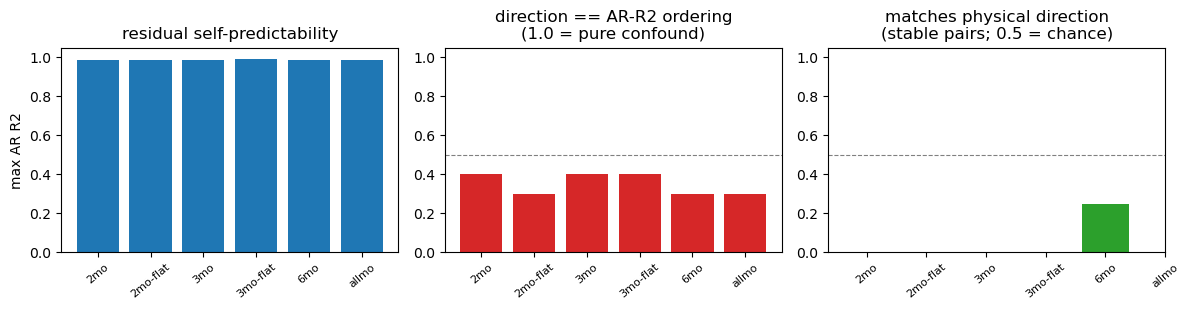

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
x = range(len(cw))
ax[0].bar(x, cw["ar_r2_max"]); ax[0].set_ylim(0, 1.05)
ax[0].set_ylabel("max AR R2"); ax[0].set_title("residual self-predictability")
ax[1].bar(x, cw["arr2_agreement"], color="tab:red")
ax[1].axhline(0.5, ls="--", c="grey", lw=.8); ax[1].set_ylim(0, 1.05)
ax[1].set_title("direction == AR-R2 ordering\n(1.0 = pure confound)")
ax[2].bar(x, cw["match_physical_stable"], color="tab:green")
ax[2].axhline(0.5, ls="--", c="grey", lw=.8); ax[2].set_ylim(0, 1.05)
ax[2].set_title("matches physical direction\n(stable pairs; 0.5 = chance)")
for a in ax:
    a.set_xticks(list(x)); a.set_xticklabels(cw["label"], rotation=40, fontsize=8)
fig.tight_layout(); plt.show()

## 5.2 Pre-drift vs full horizon, across worlds

One world could go either way by luck. Same comparison over a subset of
worlds, so the conclusion rests on the paired difference rather than a single
draw.

In [37]:
SPECS = ((2, True), (3, False), (None, True))
ws = P.sweep_windows(sub, specs=SPECS, placement=PLACEMENT, kind="flow",
                     lags=LAGS, n_sur=49, seed=SEED)
display(ws.groupby("label")[["n_steps", "ar_r2_max", "arr2_agreement",
                             "spearman_ratio_arr2", "survives_reversal_frac",
                             "peak_lag_zero_frac", "match_physical_stable",
                             "none_frac"]].agg(["mean", "std"]).round(3).T)

[1/3] Dlc__LR_LC_LC_LI_LR__baseline 44s
[2/3] Dlc__LR_LC_LC_LI_LR__baseline 361s
[3/3] Dlc__LR_LC_LC_LI_LR__baseline 178s


label                             2mo  3mo-flat      allmo
n_steps                mean  6240.000  9360.000  74880.000
                       std   5057.114  7585.671  60685.366
ar_r2_max              mean     0.996     0.997      0.996
                       std      0.007     0.005      0.007
arr2_agreement         mean     0.367     0.400      0.400
                       std      0.058     0.000      0.173
spearman_ratio_arr2    mean    -0.240     0.547      0.071
                       std      0.231     0.083      0.067
survives_reversal_frac mean     0.967     1.000      0.767
                       std      0.058     0.000      0.208
peak_lag_zero_frac     mean     1.000     1.000      0.733
                       std      0.000     0.000      0.058
match_physical_stable  mean     0.000     0.000        NaN
                       std      0.000     0.000        NaN
none_frac              mean     0.367     0.167      0.000
                       std      0.231     0.153      0.000

In [40]:
base_lbl = "3mo-flat"
piv = ws.pivot_table(index="sim_hash", columns="label",
                     values=["ar_r2_max", "arr2_agreement",
                             "match_physical_stable", "survives_reversal_frac"])
out = []
for metric in piv.columns.levels[0]:
    g = piv[metric]
    for lbl in [c for c in g.columns if c != base_lbl]:
        d = (g[lbl] - g[base_lbl]).dropna()
        if len(d):
            out.append(dict(metric=metric, window=lbl, n_worlds=len(d),
                            mean_delta=d.mean(),
                            improved=int((d < 0).sum())
                            if metric != "match_physical_stable"
                            else int((d > 0).sum())))
display(pd.DataFrame(out).round(3))
print("`improved` counts worlds moving in the DESIRABLE direction "
      "(lower AR-R2 / lower confound-agreement / lower artifact-rate, "
      "higher physical match).")

,metric,window,n_worlds,mean_delta,improved
0,ar_r2_max,2mo,3,-0.001,3
1,ar_r2_max,allmo,3,-0.001,2
2,arr2_agreement,2mo,3,-0.033,1
3,arr2_agreement,allmo,3,-0.000,2
4,match_physical_stable,2mo,3,0.000,0
5,survives_reversal_frac,2mo,3,-0.033,1
6,survives_reversal_frac,allmo,3,-0.233,2


`improved` counts worlds moving in the DESIRABLE direction (lower AR-R2 / lower confound-agreement / lower artifact-rate, higher physical match).


## 5.3 What the windowing test can and cannot settle

| outcome | conclusion |
|---|---|
| `ar_r2_max` drops a lot and `arr2_agreement` falls toward 0.5 | non-stationarity was the culprit; redo Part 4 on a pre-drift window |
| `ar_r2_max` stays ≈0.97+ regardless of window | the smooth structure is intrinsic; windowing cannot rescue lag-based direction |
| `peak_lag_zero_frac` stays 1.0 | still no precedence — the resolution, not the regime, is the binding constraint |
| `match_physical_stable` rises above chance | worth re-running the full Part-4 battery pre-drift |
| `none_frac` rises sharply | the short window has simply lost power; check `n_steps` against Part 2 |

`peak_lag_zero_frac` is the one to read first. Drift is a *level* effect; it
cannot create or destroy transport lag. If the peak stays at lag 0 in a clean
single-regime window, the contemporaneity conclusion holds and the honest
next move is sub-hourly resolution — not more windowing.

---
# Reading this end to end

- **Part 1** settles whether the toolkit is trustworthy: if
  `sc_estimators_known_truth` fails, nothing downstream is worth reading.
- **Part 2.1** says how many steps a statistic needs on a *clean* synthetic
  system; **2.2/2.3** say how many it needs on *this* network's noise and
  confound structure — usually more.
- **Part 3**'s ranking is only as meaningful as the horizon it was computed at
  (2.3) and the world-vs-strategy variance split (3.3). `variance` is the
  strategy to report: it matches `boundary` within noise without being
  selected for proximity to the pipes the AUROC label is built from.
- **Part 4** is a validity check, not a result generator. It exists to stop a
  directional claim being made on an asymmetry that time reversal, a surrogate
  null, or a regime change would have dismissed.
- **Part 5** tests whether Part 4's negative result is an artifact of mixing
  consumption regimes over 30 months. Read `peak_lag_zero_frac` first: drift is
  a level effect and cannot create transport lag, so if the cross-correlation
  peak stays at 0 in a clean pre-drift window, the contemporaneity conclusion
  stands and resolution — not regime purity — is the binding constraint.
- **`sim_seed` is fixed at 42** across the scenario sweep, so replication here
  is across drift-origin/consumption-map scenarios, not stochastic seeds. A
  small seed-only sweep is the remaining check.

Out of scope, deliberately: NSGA-II, MCDM weighting, leak simulation,
sensor-budget sweep (`TEMPLATE` fixed at 2 pressure + 3 flow).